In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/individual_approach_probability.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/individual_approach_probability.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/individual_approach_probability.csv')
df3['Condition'] = 'GH Starved-Starved'



df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/individual_approach_probability.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/individual_approach_probability.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/individual_approach_probability.csv')
df6['Condition'] = 'SI Starved-Starved'

df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)



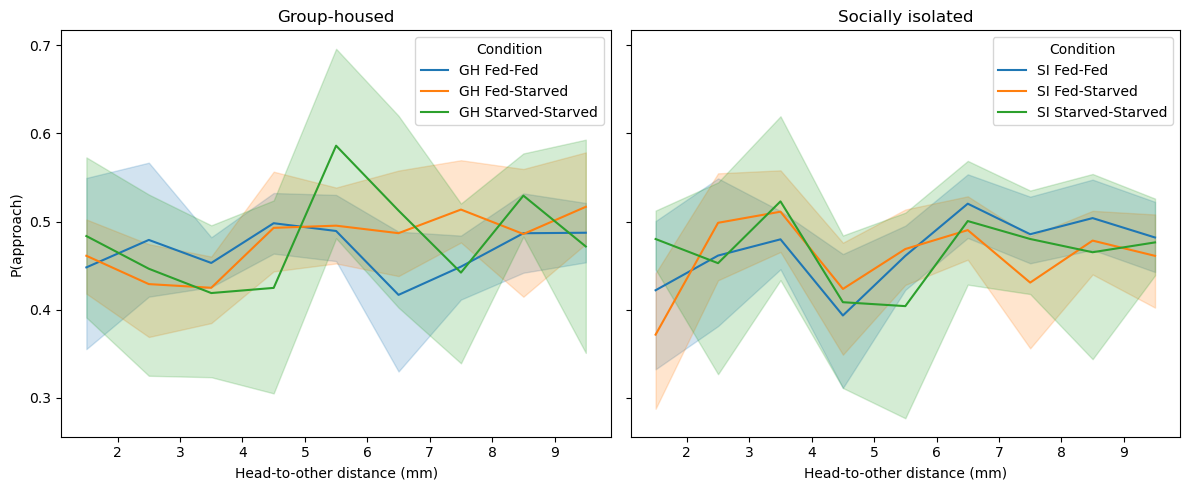

In [5]:
df_plot = df[df['distance'] >= 1].copy()

df_plot['distance_bin'] = pd.cut(
    df_plot['distance'],
    bins=np.arange(1, 11, 1),
    include_lowest=True
)

prob = (
    df_plot.groupby(['Condition', 'file', 'distance_bin'])['approach']
    .mean()
    .reset_index(name='approach_probability')
)

prob['distance_midpoint'] = (
    prob['distance_bin']
    .apply(lambda x: x.mid)
    .astype(float)
)

gh_prob = prob[prob['Condition'].str.contains('GH')]
si_prob = prob[prob['Condition'].str.contains('SI')]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.lineplot(
    data=gh_prob,
    x='distance_midpoint',
    y='approach_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Head-to-other distance (mm)')
axes[0].set_ylabel('P(approach)')

sns.lineplot(
    data=si_prob,
    x='distance_midpoint',
    y='approach_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Head-to-other distance (mm)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

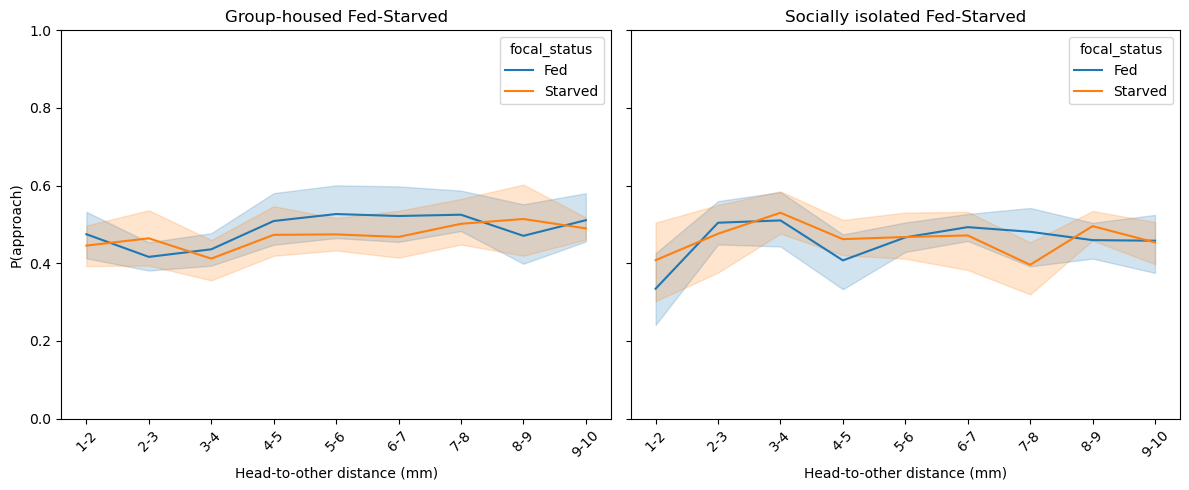

In [6]:
fed_starved = df[df['Condition'].str.contains('Fed-Starved')].copy()

fed_starved['focal_status'] = np.where(
    fed_starved['focal_id'] == 0,
    'Starved',
    'Fed'
)


fed_starved = fed_starved[fed_starved['distance'] >= 1].copy()

fed_starved['distance_bin'] = pd.cut(
    fed_starved['distance'],
    bins=np.arange(1, 11, 1),
    include_lowest=True
)

prob = (
    fed_starved
    .groupby(['Condition', 'file', 'focal_status', 'distance_bin'])['approach']
    .mean()
    .reset_index(name='approach_probability')
)

prob['distance_midpoint'] = (
    prob['distance_bin']
    .apply(lambda x: x.mid)
    .astype(float)
)

gh_prob = prob[prob['Condition'].str.contains('GH')]
si_prob = prob[prob['Condition'].str.contains('SI')]


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.lineplot(
    data=gh_prob,
    x='distance_midpoint',
    y='approach_probability',
    hue='focal_status',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('Group-housed Fed-Starved')
axes[0].set_xlabel('Head-to-other distance (mm)')
axes[0].set_ylabel('P(approach)')
axes[0].set_xticks(np.arange(1.5, 10.5, 1))
axes[0].set_xticklabels([f'{i}-{i+1}' for i in range(1, 10)], rotation=45)
axes[0].set_ylim(0, 1)

sns.lineplot(
    data=si_prob,
    x='distance_midpoint',
    y='approach_probability',
    hue='focal_status',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('Socially isolated Fed-Starved')
axes[1].set_xlabel('Head-to-other distance (mm)')
axes[1].set_ylabel('')
axes[1].set_xticks(np.arange(1.5, 10.5, 1))
axes[1].set_xticklabels([f'{i}-{i+1}' for i in range(1, 10)], rotation=45)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

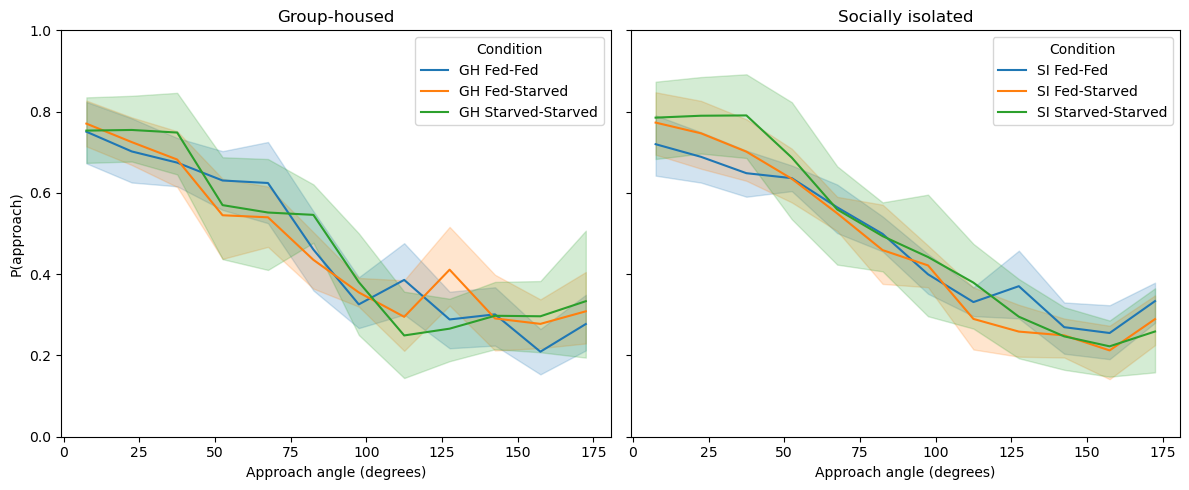

In [7]:
df['angle_bin'] = pd.cut(
    df['approach_angle'],
    bins=np.arange(0, 181, 15),
    include_lowest=True
)

prob = (
    df.groupby(['Condition', 'file', 'angle_bin'])['approach']
    .mean()
    .reset_index(name='approach_probability')
)

prob['angle_midpoint'] = (
    prob['angle_bin']
    .apply(lambda x: x.mid)
    .astype(float)
)

gh_prob = prob[prob['Condition'].str.contains('GH')]
si_prob = prob[prob['Condition'].str.contains('SI')]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.lineplot(
    data=gh_prob,
    x='angle_midpoint',
    y='approach_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Approach angle (degrees)')
axes[0].set_ylabel('P(approach)')
axes[0].set_ylim(0, 1)

sns.lineplot(
    data=si_prob,
    x='angle_midpoint',
    y='approach_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Approach angle (degrees)')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

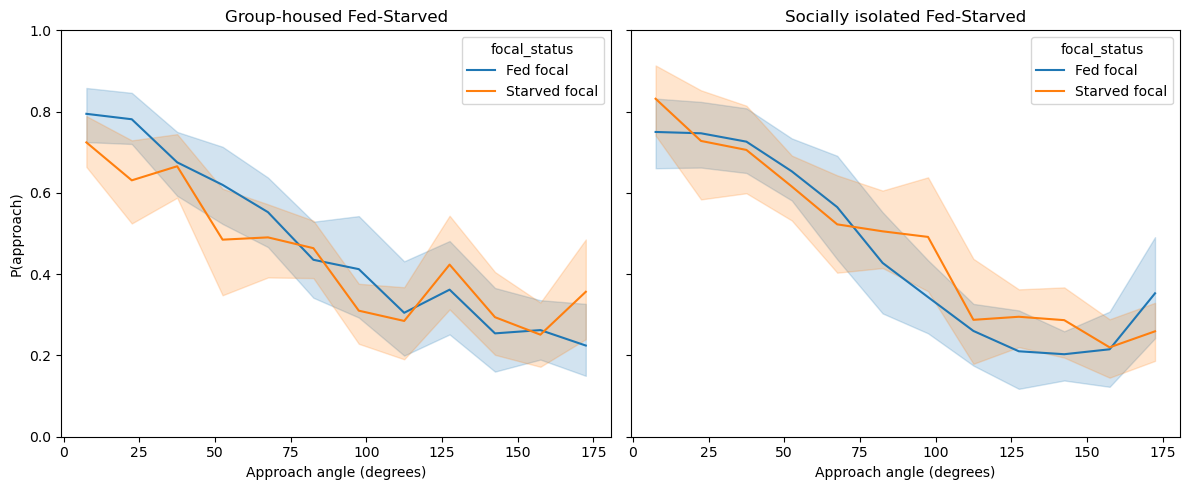

In [8]:
fed_starved = df[df['Condition'].str.contains('Fed-Starved')].copy()

fed_starved['focal_status'] = np.where(
    fed_starved['focal_id'] == 0,
    'Starved focal',
    'Fed focal'
)

fed_starved['angle_bin'] = pd.cut(
    fed_starved['approach_angle'],
    bins=np.arange(0, 181, 15),
    include_lowest=True
)

prob = (
    fed_starved
    .groupby(['Condition', 'file', 'focal_status', 'angle_bin'])['approach']
    .mean()
    .reset_index(name='approach_probability')
)

prob['angle_midpoint'] = (
    prob['angle_bin']
    .apply(lambda x: x.mid)
    .astype(float)
)

gh_prob = prob[prob['Condition'].str.contains('GH')]
si_prob = prob[prob['Condition'].str.contains('SI')]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.lineplot(
    data=gh_prob,
    x='angle_midpoint',
    y='approach_probability',
    hue='focal_status',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('Group-housed Fed-Starved')
axes[0].set_xlabel('Approach angle (degrees)')
axes[0].set_ylabel('P(approach)')
axes[0].set_ylim(0, 1)

sns.lineplot(
    data=si_prob,
    x='angle_midpoint',
    y='approach_probability',
    hue='focal_status',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('Socially isolated Fed-Starved')
axes[1].set_xlabel('Approach angle (degrees)')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

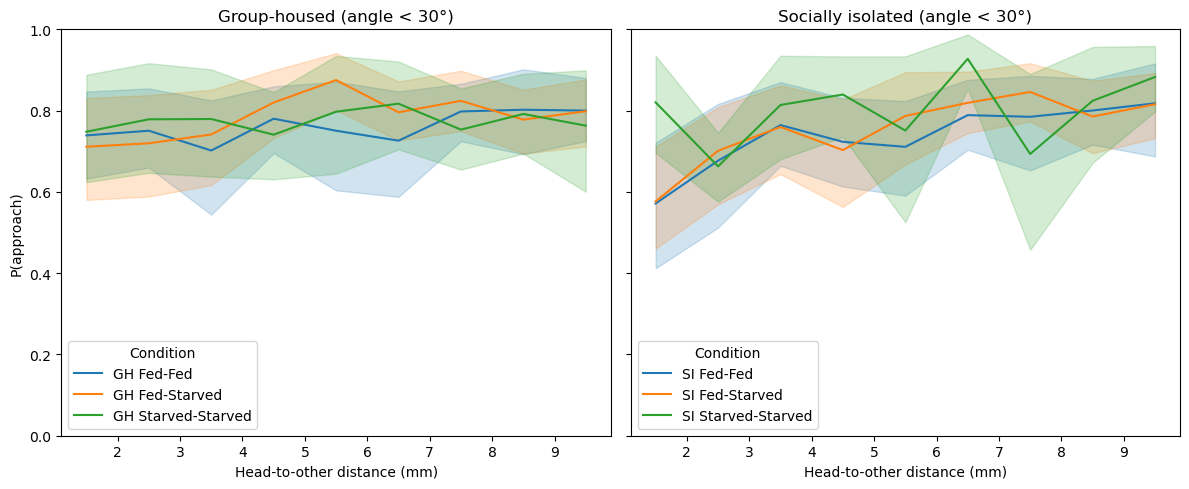

In [9]:
df_facing = df[df['approach_angle'] < 30].copy()

df_facing['distance_bin'] = pd.cut(
    df_facing['distance'],
    bins=np.arange(1, 11, 1),
    include_lowest=True
)

prob = (
    df_facing
    .groupby(['Condition', 'file', 'distance_bin'])['approach']
    .mean()
    .reset_index(name='approach_probability')
)

prob['distance_midpoint'] = (
    prob['distance_bin']
    .apply(lambda x: x.mid)
    .astype(float)
)

gh_prob = prob[prob['Condition'].str.contains('GH')]
si_prob = prob[prob['Condition'].str.contains('SI')]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.lineplot(
    data=gh_prob,
    x='distance_midpoint',
    y='approach_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('Group-housed (angle < 30°)')
axes[0].set_xlabel('Head-to-other distance (mm)')
axes[0].set_ylabel('P(approach)')
axes[0].set_ylim(0, 1)

sns.lineplot(
    data=si_prob,
    x='distance_midpoint',
    y='approach_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('Socially isolated (angle < 30°)')
axes[1].set_xlabel('Head-to-other distance (mm)')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

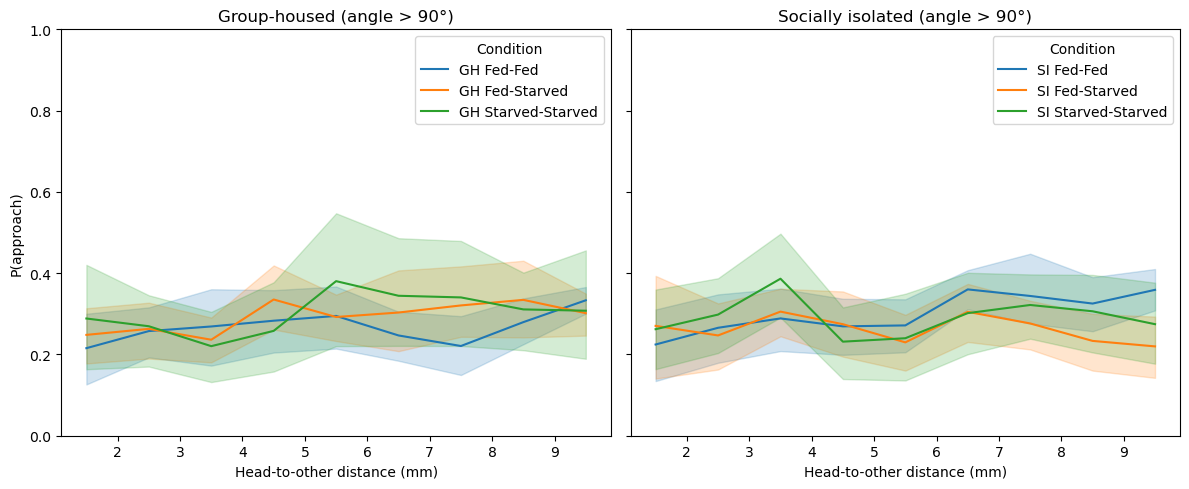

In [10]:
df_not_facing = df[df['approach_angle'] > 90].copy()

df_not_facing['distance_bin'] = pd.cut(
    df_not_facing['distance'],
    bins=np.arange(1, 11, 1),
    include_lowest=True
)

prob = (
    df_not_facing
    .groupby(['Condition', 'file', 'distance_bin'])['approach']
    .mean()
    .reset_index(name='approach_probability')
)

prob['distance_midpoint'] = (
    prob['distance_bin']
    .apply(lambda x: x.mid)
    .astype(float)
)

gh_prob = prob[prob['Condition'].str.contains('GH')]
si_prob = prob[prob['Condition'].str.contains('SI')]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.lineplot(
    data=gh_prob,
    x='distance_midpoint',
    y='approach_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('Group-housed (angle > 90°)')
axes[0].set_xlabel('Head-to-other distance (mm)')
axes[0].set_ylabel('P(approach)')
axes[0].set_ylim(0, 1)

sns.lineplot(
    data=si_prob,
    x='distance_midpoint',
    y='approach_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('Socially isolated (angle > 90°)')
axes[1].set_xlabel('Head-to-other distance (mm)')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_39734/2529039452.py:22: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


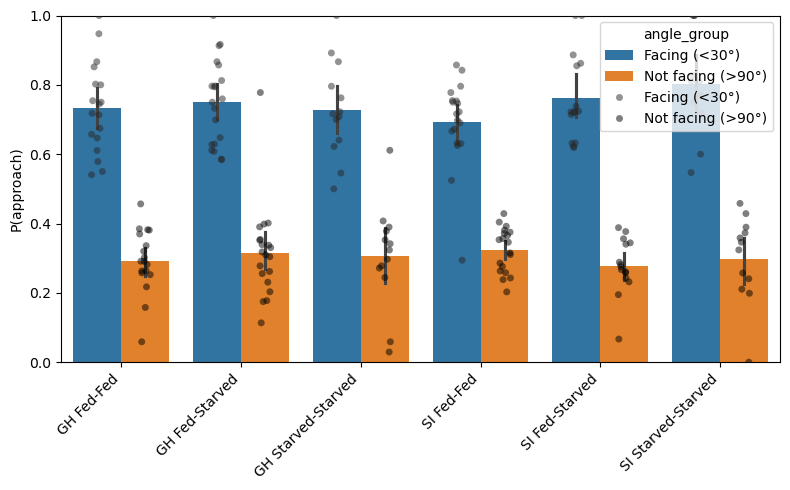

In [11]:
df['angle_group'] = np.where(
    df['approach_angle'] < 30,
    'Facing (<30°)',
    np.where(df['approach_angle'] > 90, 'Not facing (>90°)', 'Intermediate')
)

summary = (
    df[df['angle_group'] != 'Intermediate']
    .groupby(['Condition', 'file', 'angle_group'])['approach']
    .mean()
    .reset_index(name='approach_probability')
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=summary,
    x='Condition',
    y='approach_probability',
    hue='angle_group',
    errorbar=('ci', 95)
)
sns.stripplot(
    data=summary,
    x='Condition',
    y='approach_probability',
    hue='angle_group',
    dodge=True,
    color='black',
    alpha=0.5
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('P(approach)')
plt.xlabel('')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [12]:
df = df.sort_values(['Condition', 'file', 'focal_id', 'stim_id', 'frame']).copy()

df['touch_success'] = False

for (condition, file, focal_id, stim_id), group in df.groupby(
    ['Condition', 'file', 'focal_id', 'stim_id']
):

    idxs = group.index.to_numpy()
    distances = group['distance'].to_numpy()

    for i in range(len(group)):

        start_distance = distances[i]
        success = False

        for j in range(i + 1, len(group)):

            if distances[j] < 1:
                success = True
                break

            if distances[j] > start_distance:
                success = False
                break

        df.loc[idxs[i], 'touch_success'] = success

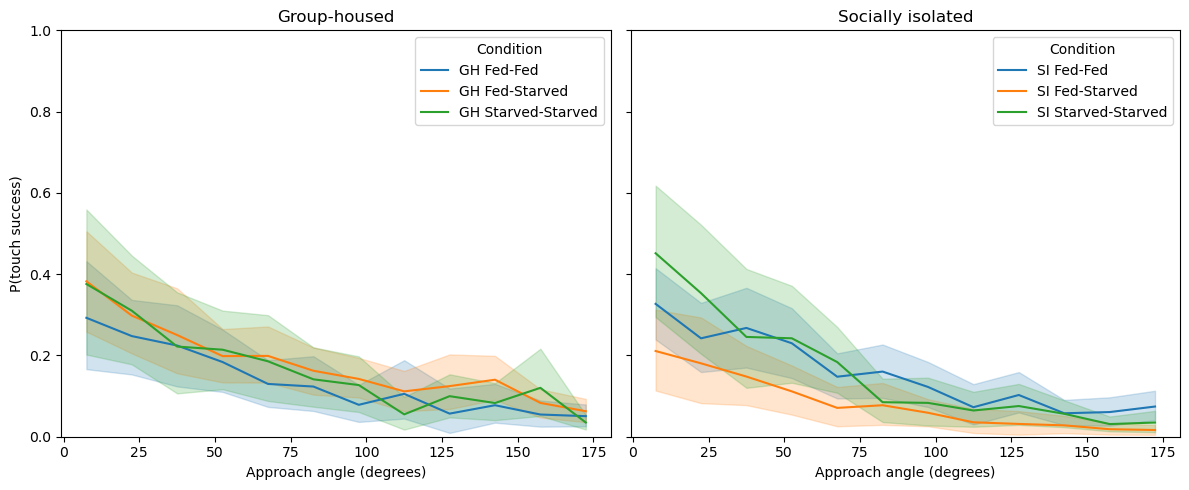

In [13]:
df['angle_bin'] = pd.cut(
    df['approach_angle'],
    bins=np.arange(0, 181, 15),
    include_lowest=True
)

touch_angle = (
    df.groupby(['Condition', 'file', 'angle_bin'])['touch_success']
    .mean()
    .reset_index(name='touch_probability')
)

touch_angle['angle_midpoint'] = (
    touch_angle['angle_bin']
    .apply(lambda x: x.mid)
    .astype(float)
)

gh = touch_angle[touch_angle['Condition'].str.contains('GH')]
si = touch_angle[touch_angle['Condition'].str.contains('SI')]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.lineplot(
    data=gh,
    x='angle_midpoint',
    y='touch_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Approach angle (degrees)')
axes[0].set_ylabel('P(touch success)')
axes[0].set_ylim(0, 1)

sns.lineplot(
    data=si,
    x='angle_midpoint',
    y='touch_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Approach angle (degrees)')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [15]:
df['touch_success'].mean()

0.17707299083713937

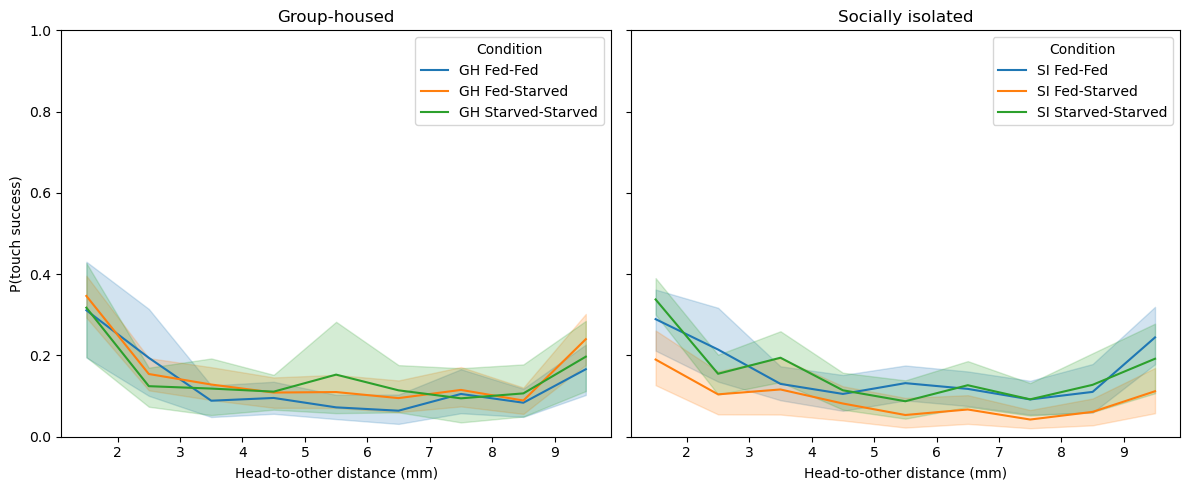

In [16]:
df_plot = df[df['distance'] >= 1].copy()

df_plot['distance_bin'] = pd.cut(
    df_plot['distance'],
    bins=np.arange(1, 11, 1),
    include_lowest=True
)

prob = (
    df_plot.groupby(['Condition', 'file', 'distance_bin'])['touch_success']
    .mean()
    .reset_index(name='touch_probability')
)

prob['distance_midpoint'] = (
    prob['distance_bin']
    .apply(lambda x: x.mid)
    .astype(float)
)

gh_prob = prob[prob['Condition'].str.contains('GH')]
si_prob = prob[prob['Condition'].str.contains('SI')]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.lineplot(
    data=gh_prob,
    x='distance_midpoint',
    y='touch_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('Group-housed')
axes[0].set_xlabel('Head-to-other distance (mm)')
axes[0].set_ylabel('P(touch success)')
axes[0].set_ylim(0, 1)

sns.lineplot(
    data=si_prob,
    x='distance_midpoint',
    y='touch_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('Socially isolated')
axes[1].set_xlabel('Head-to-other distance (mm)')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

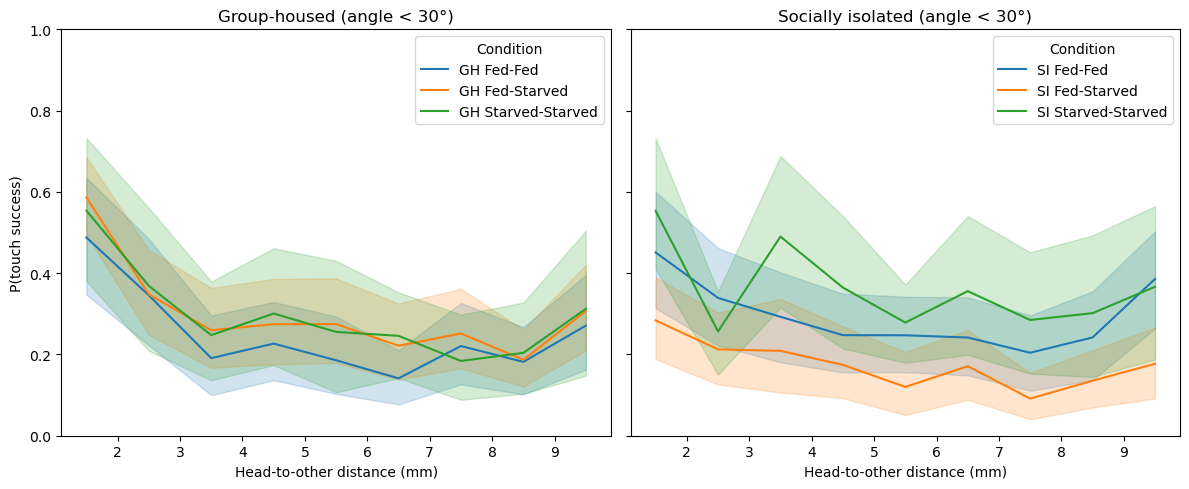

In [ ]:
df_facing = df[
    (df['approach_angle'] < 30) &
    (df['distance'] >= 1)
].copy()

df_facing['distance_bin'] = pd.cut(
    df_facing['distance'],
    bins=np.arange(1, 11, 1),
    include_lowest=True
)

prob_facing = (
    df_facing.groupby(['Condition', 'file', 'distance_bin'])['touch_success']
    .mean()
    .reset_index(name='touch_probability')
)

prob_facing['distance_midpoint'] = (
    prob_facing['distance_bin']
    .apply(lambda x: x.mid)
    .astype(float)
)

gh_prob = prob_facing[prob_facing['Condition'].str.contains('GH')]
si_prob = prob_facing[prob_facing['Condition'].str.contains('SI')]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.lineplot(
    data=gh_prob,
    x='distance_midpoint',
    y='touch_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('Group-housed (angle < 30°)')
axes[0].set_xlabel('Head-to-other distance (mm)')
axes[0].set_ylabel('P(touch success)')
axes[0].set_ylim(0, 1)

sns.lineplot(
    data=si_prob,
    x='distance_midpoint',
    y='touch_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('Socially isolated (angle < 30°)')
axes[1].set_xlabel('Head-to-other distance (mm)')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [19]:
df_facing = df[df['approach_angle'] < 30]
df_facing['touch_success'].mean()


0.35365326415910076

In [20]:

df_not_facing = df[df['approach_angle'] > 90]
df_not_facing['touch_success'].mean()

0.09455459368891371

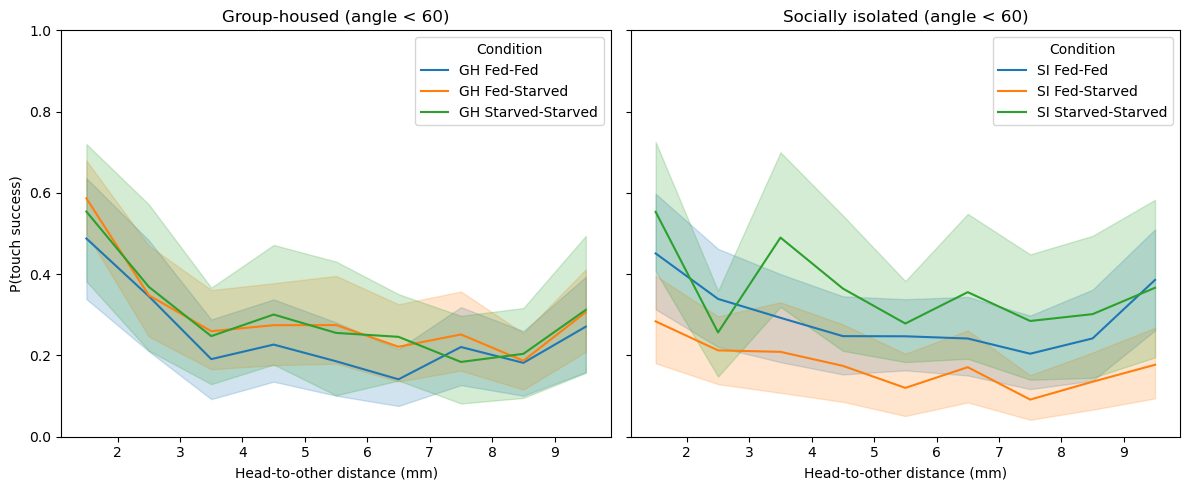

In [22]:
df_facing = df[
    (df['approach_angle'] < 60) &
    (df['distance'] >= 1)
].copy()

df_facing['distance_bin'] = pd.cut(
    df_facing['distance'],
    bins=np.arange(1, 11, 1),
    include_lowest=True
)

prob_facing = (
    df_facing.groupby(['Condition', 'file', 'distance_bin'])['touch_success']
    .mean()
    .reset_index(name='touch_probability')
)

prob_facing['distance_midpoint'] = (
    prob_facing['distance_bin']
    .apply(lambda x: x.mid)
    .astype(float)
)

gh_prob = prob_facing[prob_facing['Condition'].str.contains('GH')]
si_prob = prob_facing[prob_facing['Condition'].str.contains('SI')]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.lineplot(
    data=gh_prob,
    x='distance_midpoint',
    y='touch_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('Group-housed (angle < 60)')
axes[0].set_xlabel('Head-to-other distance (mm)')
axes[0].set_ylabel('P(touch success)')
axes[0].set_ylim(0, 1)

sns.lineplot(
    data=si_prob,
    x='distance_midpoint',
    y='touch_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('Socially isolated (angle < 60)')
axes[1].set_xlabel('Head-to-other distance (mm)')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

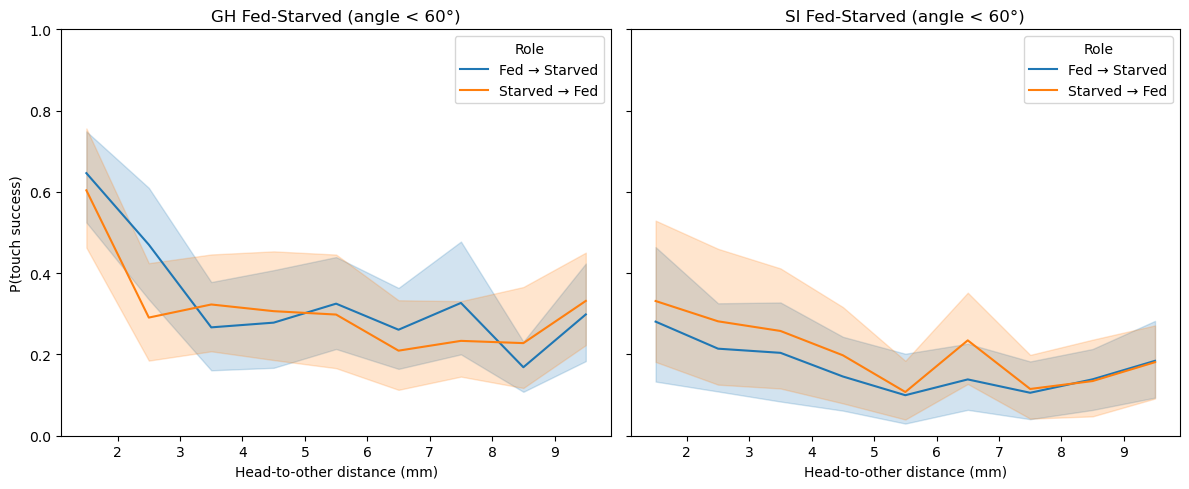

In [26]:
df_fs = df[
    (df['Condition'].str.contains('Fed-Starved')) &
    (df['approach_angle'] < 60) &
    (df['distance'] >= 1)
].copy()

df_fs['Role'] = np.where(
    df_fs['focal_id'] == 0,
    'Starved → Fed',
    'Fed → Starved'
)

df_fs['distance_bin'] = pd.cut(
    df_fs['distance'],
    bins=np.arange(1, 11, 1),
    include_lowest=True
)

prob = (
    df_fs.groupby(
        ['Condition', 'file', 'Role', 'distance_bin']
    )['touch_success']
    .mean()
    .reset_index(name='touch_probability')
)

prob['distance_midpoint'] = (
    prob['distance_bin']
    .apply(lambda x: x.mid)
    .astype(float)
)

gh_prob = prob[prob['Condition'] == 'GH Fed-Starved']
si_prob = prob[prob['Condition'] == 'SI Fed-Starved']

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.lineplot(
    data=gh_prob,
    x='distance_midpoint',
    y='touch_probability',
    hue='Role',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('GH Fed-Starved (angle < 60°)')
axes[0].set_xlabel('Head-to-other distance (mm)')
axes[0].set_ylabel('P(touch success)')
axes[0].set_ylim(0, 1)

sns.lineplot(
    data=si_prob,
    x='distance_midpoint',
    y='touch_probability',
    hue='Role',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('SI Fed-Starved (angle < 60°)')
axes[1].set_xlabel('Head-to-other distance (mm)')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

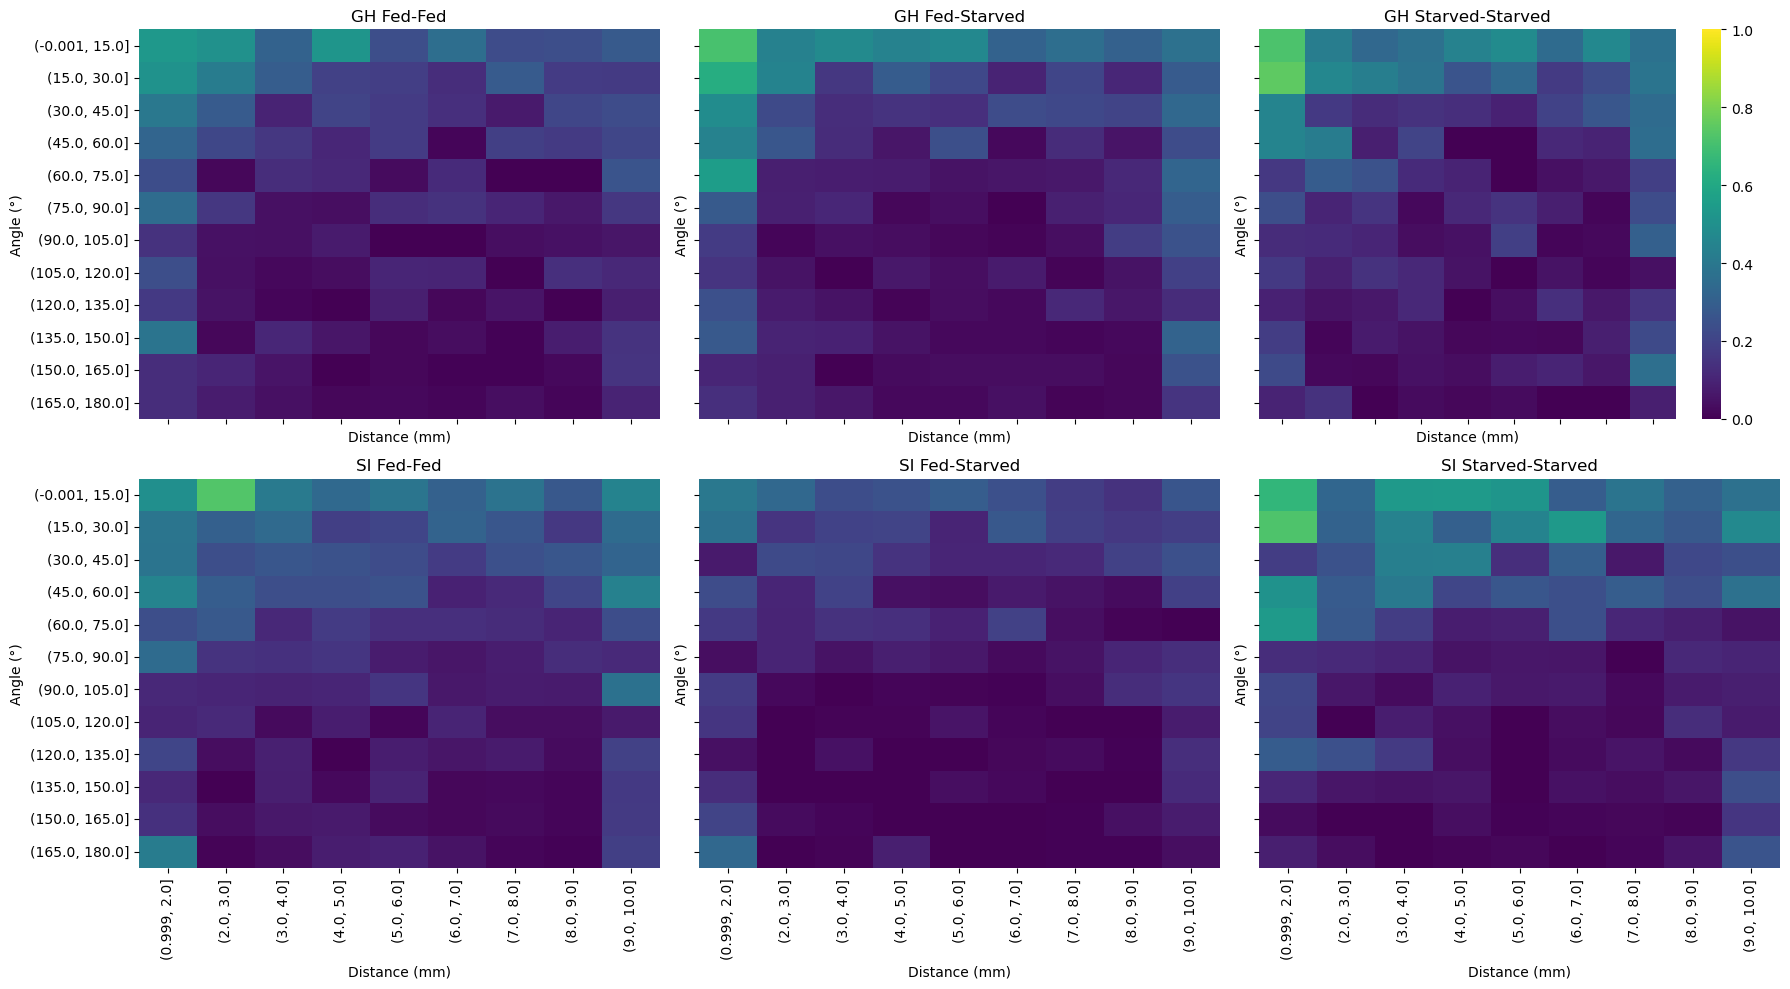

In [23]:
df_heat = df.copy()

df_heat = df_heat[df_heat['distance'] >= 1]

df_heat['distance_bin'] = pd.cut(
    df_heat['distance'],
    bins=np.arange(1, 11, 1),
    include_lowest=True
)

df_heat['angle_bin'] = pd.cut(
    df_heat['approach_angle'],
    bins=np.arange(0, 181, 15),
    include_lowest=True
)

heatmap_df = (
    df_heat
    .groupby(
        ['Condition', 'file', 'distance_bin', 'angle_bin']
    )['touch_success']
    .mean()
    .reset_index()
)

heatmap_mean = (
    heatmap_df
    .groupby(
        ['Condition', 'distance_bin', 'angle_bin']
    )['touch_success']
    .mean()
    .reset_index()
)

conditions = [
    'GH Fed-Fed',
    'GH Fed-Starved',
    'GH Starved-Starved',
    'SI Fed-Fed',
    'SI Fed-Starved',
    'SI Starved-Starved'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)

for ax, condition in zip(axes.flatten(), conditions):

    plot_df = heatmap_mean[
        heatmap_mean['Condition'] == condition
    ]

    pivot = plot_df.pivot(
        index='angle_bin',
        columns='distance_bin',
        values='touch_success'
    )

    sns.heatmap(
        pivot,
        ax=ax,
        cmap='viridis',
        vmin=0,
        vmax=1,
        cbar=ax == axes[0, 2]  # only one colourbar
    )

    ax.set_title(condition)
    ax.set_xlabel('Distance (mm)')
    ax.set_ylabel('Angle (°)')

plt.tight_layout()
plt.show()

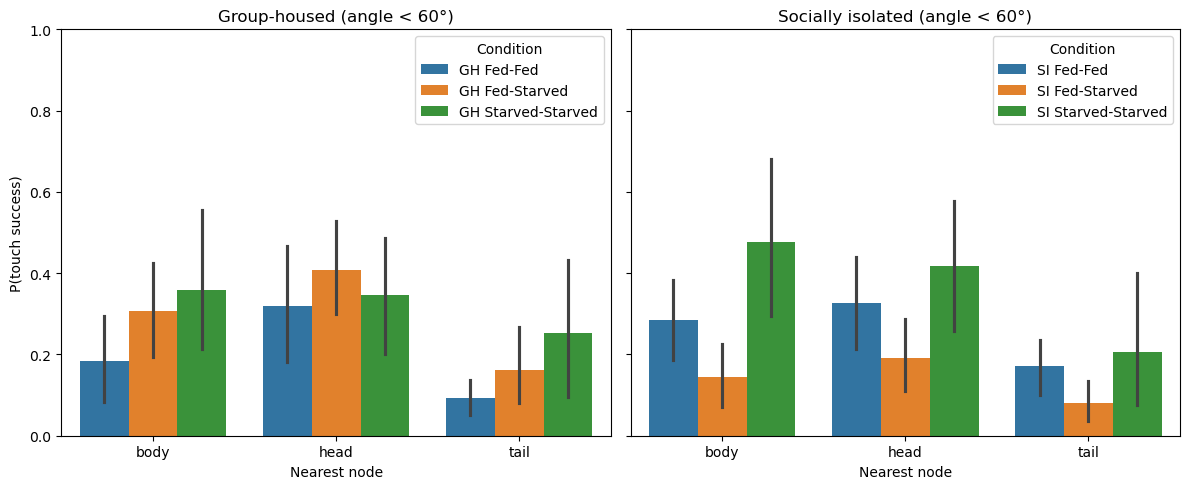

In [27]:
df_facing = df[
    (df['approach_angle'] < 60) &
    (df['distance'] >= 1)
].copy()

prob_node = (
    df_facing
    .groupby(['Condition', 'file', 'nearest_node'])['touch_success']
    .mean()
    .reset_index(name='touch_probability')
)

gh = prob_node[prob_node['Condition'].str.contains('GH')]
si = prob_node[prob_node['Condition'].str.contains('SI')]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.barplot(
    data=gh,
    x='nearest_node',
    y='touch_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('Group-housed (angle < 60°)')
axes[0].set_xlabel('Nearest node')
axes[0].set_ylabel('P(touch success)')
axes[0].set_ylim(0, 1)

sns.barplot(
    data=si,
    x='nearest_node',
    y='touch_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('Socially isolated (angle < 60°)')
axes[1].set_xlabel('Nearest node')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

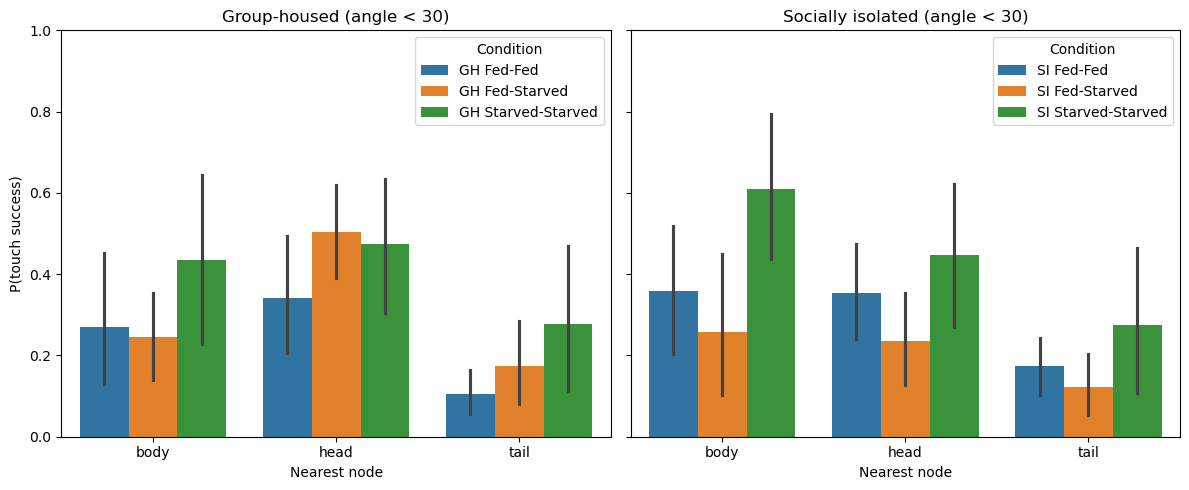

In [28]:
df_facing = df[
    (df['approach_angle'] < 30) &
    (df['distance'] >= 1)
].copy()

prob_node = (
    df_facing
    .groupby(['Condition', 'file', 'nearest_node'])['touch_success']
    .mean()
    .reset_index(name='touch_probability')
)

gh = prob_node[prob_node['Condition'].str.contains('GH')]
si = prob_node[prob_node['Condition'].str.contains('SI')]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.barplot(
    data=gh,
    x='nearest_node',
    y='touch_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('Group-housed (angle < 30)')
axes[0].set_xlabel('Nearest node')
axes[0].set_ylabel('P(touch success)')
axes[0].set_ylim(0, 1)

sns.barplot(
    data=si,
    x='nearest_node',
    y='touch_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('Socially isolated (angle < 30)')
axes[1].set_xlabel('Nearest node')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

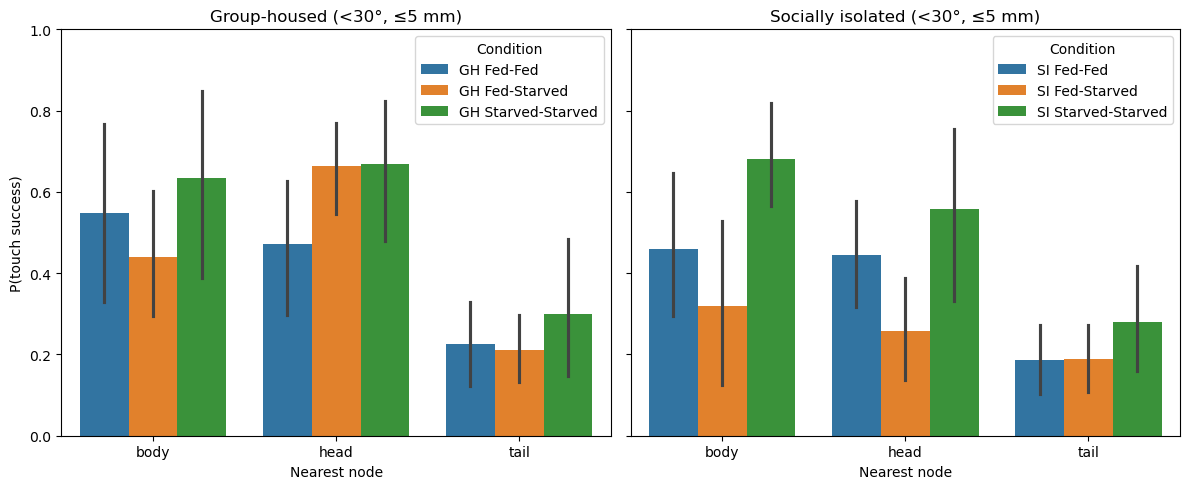

In [29]:
df_facing = df[
    (df['approach_angle'] < 30) &
    (df['distance'] <= 5)
].copy()

prob_node = (
    df_facing
    .groupby(['Condition', 'file', 'nearest_node'])['touch_success']
    .mean()
    .reset_index(name='touch_probability')
)

gh = prob_node[prob_node['Condition'].str.contains('GH')]
si = prob_node[prob_node['Condition'].str.contains('SI')]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.barplot(
    data=gh,
    x='nearest_node',
    y='touch_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].set_title('Group-housed (<30°, ≤5 mm)')
axes[0].set_xlabel('Nearest node')
axes[0].set_ylabel('P(touch success)')
axes[0].set_ylim(0, 1)

sns.barplot(
    data=si,
    x='nearest_node',
    y='touch_probability',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].set_title('Socially isolated (<30°, ≤5 mm)')
axes[1].set_xlabel('Nearest node')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

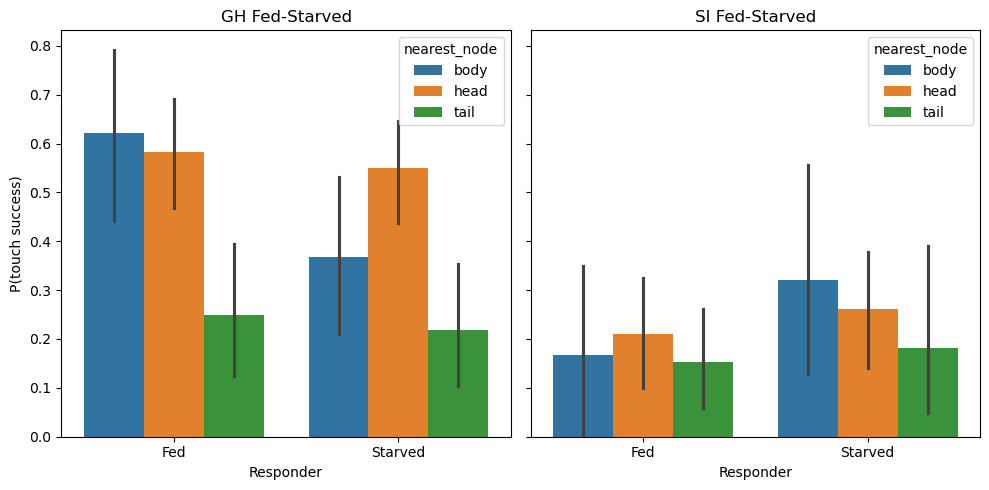

In [32]:
df_fs = df[
    df['Condition'].isin(['GH Fed-Starved', 'SI Fed-Starved'])
].copy()

df_fs['Responder'] = np.where(
    df_fs['focal_id'] == 0,
    'Starved',
    'Fed'
)

df_fs = df_fs[
    (df_fs['approach_angle'] < 60) &
    (df_fs['distance'] <= 5)
]

prob = (
    df_fs
    .groupby(['Condition', 'file', 'nearest_node', 'Responder'])['touch_success']
    .mean()
    .reset_index(name='touch_probability')
)

fig, axes = plt.subplots(1, 2, figsize=(10,5), sharey=True)

sns.barplot(
    data=prob[prob['Condition'] == 'GH Fed-Starved'],
    x='Responder',
    y='touch_probability',
        hue='nearest_node',
    errorbar=('ci',95),
    ax=axes[0]
)

axes[0].set_title('GH Fed-Starved')
axes[0].set_ylabel('P(touch success)')

sns.barplot(
    data=prob[prob['Condition'] == 'SI Fed-Starved'],
    x='Responder',
    y='touch_probability',
        hue='nearest_node',
    errorbar=('ci',95),
    ax=axes[1]
)

axes[1].set_title('SI Fed-Starved')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()